In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [133]:
plt.rcParams['figure.figsize'] = [15, 5]

# Завантаження фото
img1 = cv2.imread(r"C:\Users\User\Downloads\22.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(r"C:\Users\User\Downloads\44.jpg")
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

**White Patch**

Ідея алгоритму:
припускається, що найсвітліший піксель на зображенні має бути білим.

In [126]:
def white_patch(img):
    # вибираємо піксель, який вважаємо білим
    row, col = 485, 567
    white = img[row, col, :]
    
    # обчислюємо коефіцієнти масштабування для каналів
    coeffs = 255.0 / white

    # створюємо нове зображення
    balanced = np.zeros_like(img, dtype=np.float32)

    for channel in range(3):
        balanced[..., channel] = img[..., channel] * coeffs[channel]

    balanced = balanced / 255
    balanced[balanced > 1] = 1

    return balanced

balanced1 = white_patch(img1)
balanced2 = white_patch(img2)

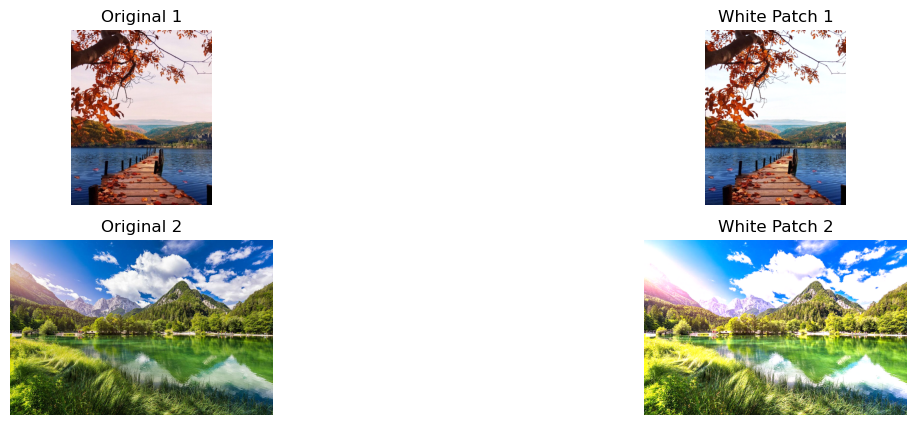

In [116]:
plt.figure()

plt.subplot(2,2,1)
plt.imshow(img1)
plt.title("Original 1")
plt.axis(False)

plt.subplot(2,2,2)
plt.imshow(balanced1)
plt.title("White Patch 1")
plt.axis(False)

plt.subplot(2,2,3)
plt.imshow(img2)
plt.title("Original 2")
plt.axis(False)

plt.subplot(2,2,4)
plt.imshow(balanced2)
plt.title("White Patch 2")
plt.axis(False)

plt.show()

**Gray World**

Ідея алгоритму: середній колір сцени повинен бути сірим.

In [128]:
img11 = cv2.imread("C:/Users/User/Downloads/101.jpg")
img11 = cv2.cvtColor(img11, cv2.COLOR_BGR2RGB)

img22 = cv2.imread("C:/Users/User/Downloads/77.jpg")
img22 = cv2.cvtColor(img22, cv2.COLOR_BGR2RGB)

def gray_world(img):
    
    # обчислення середніх значень кольорових каналів
    mean_r = np.mean(img[:,:,0])
    mean_g = np.mean(img[:,:,1])
    mean_b = np.mean(img[:,:,2])

    # коефіцієнти балансування
    kg = 1
    kr = mean_g / mean_r
    kb = mean_g / mean_b

    # створення нового зображення
    balanced = np.zeros_like(img, dtype=np.float32)

    # масштабування каналів
    balanced[:,:,0] = img[:,:,0] * kr
    balanced[:,:,1] = img[:,:,1] * kg
    balanced[:,:,2] = img[:,:,2] * kb

    balanced = balanced / 255
    balanced[balanced > 1] = 1

    return balanced

balanced11 = gray_world(img11)
balanced22 = gray_world(img22)

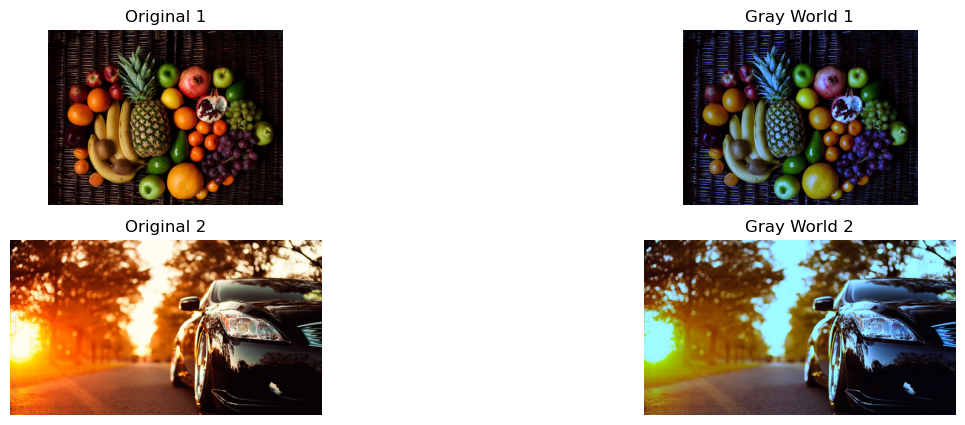

In [105]:
plt.figure()

plt.subplot(2,2,1)
plt.imshow(img11)

plt.title("Original 1")
plt.axis(False)

plt.subplot(2,2,2)
plt.imshow(balanced11)
plt.title("Gray World 1")
plt.axis(False)

plt.subplot(2,2,3)
plt.imshow(img22)
plt.title("Original 2")
plt.axis(False)

plt.subplot(2,2,4)
plt.imshow(balanced22)
plt.title("Gray World 2")
plt.axis(False)

plt.show()

**Scale-by-Max**

Ідея алгоритму: кожен канал масштабується так, щоб його максимальне значення стало 255.

In [130]:
# Load image
img33 = cv2.imread("C:/Users/User/Downloads/88.jpg")
img33 = cv2.cvtColor(img33, cv2.COLOR_BGR2RGB)

img44 = cv2.imread("C:/Users/User/Downloads/100.jpg")
img44 = cv2.cvtColor(img44, cv2.COLOR_BGR2RGB)

def scale_by_max(img):
    
    # максимальні значення каналів
    max_r = np.max(img[:,:,0])
    max_g = np.max(img[:,:,1])
    max_b = np.max(img[:,:,2])

    # створення нового зображення
    balanced = np.zeros_like(img, dtype=np.float32)

    # масштабування каналів
    balanced[:,:,0] = img[:,:,0] * (255.0 / max_r)
    balanced[:,:,1] = img[:,:,1] * (255.0 / max_g)
    balanced[:,:,2] = img[:,:,2] * (255.0 / max_b)

    # нормалізація
    balanced = balanced / 255
    balanced[balanced > 1] = 1

    return balanced

balanced33 = scale_by_max(img33)
balanced44 = scale_by_max(img44)

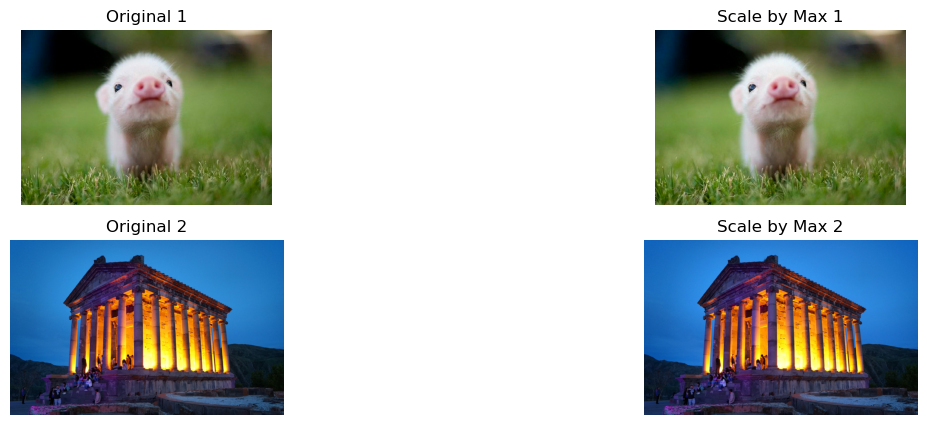

In [124]:
plt.figure()

plt.subplot(2,2,1)
plt.imshow(img33)
plt.title("Original 1")
plt.axis(False)

plt.subplot(2,2,2)
plt.imshow(balanced33)
plt.title("Scale by Max 1")
plt.axis(False)

plt.subplot(2,2,3)
plt.imshow(img44)
plt.title("Original 2")
plt.axis(False)

plt.subplot(2,2,4)
plt.imshow(balanced44)
plt.title("Scale by Max 2")
plt.axis(False)

plt.show()

**Висновки**

У лабораторній роботі були реалізовані три алгоритми балансування кольору: White Patch, Gray World та Scale-by-Max.

Алгоритм White Patch базується на припущенні, що найсвітліший піксель на зображенні повинен бути білим. Для цього обирається один піксель і на основі його значень обчислюються коефіцієнти масштабування для кожного каналу.

Алгоритм Gray World виходить з припущення, що середнє значення кольорів сцени має бути сірим. Для цього обчислюються середні значення каналів та масштабуються так, щоб вони були однаковими.

Алгоритм Scale-by-Max масштабує кожен канал відповідно до його максимального значення, щоб максимально використовувати динамічний діапазон.

Після застосування алгоритмів зображення отримують більш природній баланс кольорів та компенсується вплив освітлення.

**Відповіді на питання**

1. Які результати дають різні піксельні операції на різних зображеннях?
Різні піксельні операції змінюють кольоровий баланс зображення по-різному. Деякі методи роблять кольори більш природними, інші можуть зробити зображення світлішим або змінити відтінок.

2. Чому так відбувається?
Це відбувається тому, що кожен алгоритм використовує різний спосіб обчислення коефіцієнтів для корекції кольорових каналів. Через різний розподіл кольорів та освітлення на зображеннях результати можуть відрізнятися.

3. На яких зображеннях, на вашу думку, яку піксельну операцію краще застосовувати?
Алгоритм White Patch добре працює на зображеннях, де є білий або дуже світлий об'єкт. Gray World підходить для зображень з різноманітними кольорами, де середній колір сцени близький до сірого. Scale-by-Max краще використовувати для зображень, де потрібно підсилити контраст кольорових каналів.

**Додатково**

In [161]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15,5]

img111 = cv2.imread("C:/Users/User/Downloads/33.jpg")
img111 = cv2.cvtColor(img111, cv2.COLOR_BGR2RGB)

In [154]:
# Перетворення RGB → HSV
hsv = cv2.cvtColor(img111, cv2.COLOR_RGB2HSV)

# Розділення каналів
h, s, v = cv2.split(hsv)

# Еквалізація гістограми для каналу V
v_eq = cv2.equalizeHist(v)

# Об’єднання каналів назад
hsv_eq = cv2.merge([h, s, v_eq])

# Перетворення назад у RGB
result = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)

(-0.5, 999.5, 666.5, -0.5)

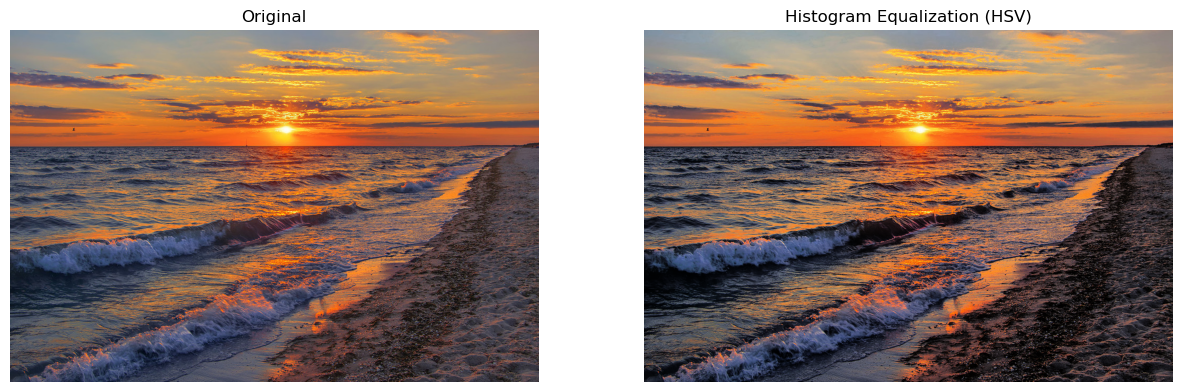

In [156]:
plt.subplot(121)
plt.imshow(img111)
plt.title("Original")
plt.axis(False)

plt.subplot(122)
plt.imshow(result)
plt.title("Histogram Equalization (HSV)")
plt.axis(False)

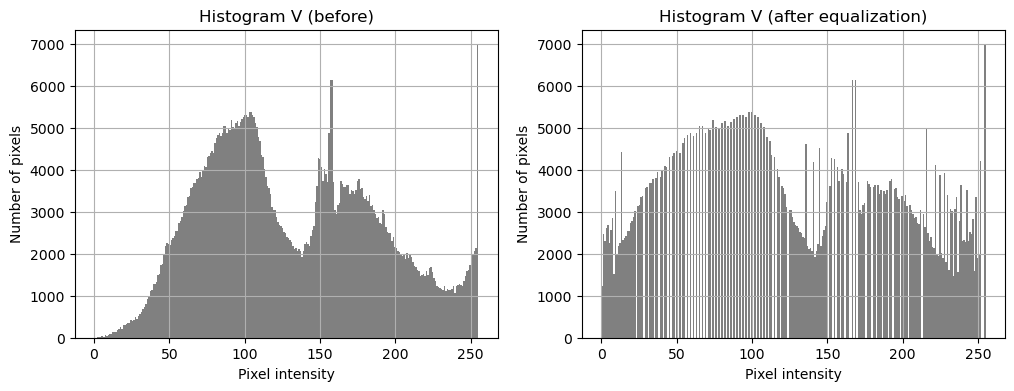

In [159]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(v.ravel(), bins=256, range=(0,255), color='gray')
plt.title("Histogram V (before)")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.grid(True)

plt.subplot(1,2,2)
plt.hist(v_eq.ravel(), bins=256, range=(0,255), color='gray')
plt.title("Histogram V (after equalization)")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.grid(True)

plt.show()

До еквалізації пікселі можуть бути скупчені в певному діапазоні (наприклад, темні або світлі).
Після еквалізації розподіл стає більш рівномірним -> зображення виглядає контрастнішим. На прикладі видно, що зображення стало чіткішим, темні відтінки стали темніші, а світлі в свою чергу світліші.